# Module imports

In [1]:
from pathlib import Path
import jax.numpy as np
from jax.lax import broadcast_in_dim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MRSUN_SI, MTSUN_SI, uGpc
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal
import gwfast.network as network
from gwfast.lensing_utils import \
    get_agn_lensed_parameters, \
    PML_time_delay_magnification, \
    dLGridGlob, zGridGlob, einstein_angle

from pycbc.filter import match
from pycbc.types.frequencyseries import FrequencySeries

from tqdm import tqdm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

/Users/yuranzhang/gwfast_AGN/gwfast_moddd/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


# Function definitions

## Normal lens definition

In [2]:
# Normal lensing (first order effects) definition
# Yes, this needs to be simplified...
def normal_lens(FD_strain, events, freqs, separate=False):
    r_orbit = events['R_orbit']
    lens_mass = events['M_lz']
    luminosity_distance = events["dL"]
    y_src = events["src_pos"]
    d_LS = r_orbit * np.sqrt(1 - y_src**2)  # R_Sch
    _y_src = y_src * r_orbit  # R_Sch

    # Schwarschild radius
    # A small, but necessary assumption, that the lens is at dL
    z = np.interp(luminosity_distance, dLGridGlob, zGridGlob)
    lens_mass_src = lens_mass / (1 + z)
    R_Sch = 2 * lens_mass_src * MRSUN_SI  # m
    delta = R_Sch / uGpc

    beta = _y_src / luminosity_distance * delta  # Radian
    ang_D_S = luminosity_distance

    ang_D_L = ang_D_S / (1 + d_LS * delta)  # Gpc
    theta_E = einstein_angle(lens_mass_src, ang_D_L, ang_D_S)  # Radian
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
    time_delay *= lens_mass_src * MTSUN_SI  
    time_delay_phase_shift = np.exp(2j * np.pi * freqs * time_delay)

    image_1 = mag_1 * FD_strain
    image_2 = mag_2 * FD_strain * time_delay_phase_shift
    if separate:
        return image_1, image_2
    else:
        return image_1 + image_2

## `convert_y_to_src_pos` definition

In [3]:
def convert_y_to_src_pos(y, R_orbit, rs=1):
    # Convert source position from units of Einstein radius to units of R_orbit
    # Returns a 2D grid of src_pos with shape (len(y), len(R_orbit))
    Dls_min = (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs # for rs=1, this is in units of R_S
    theta_E = np.sqrt(2 * Dls_min) # Einstein radius in units of R_S
    src_pos = np.outer(y, theta_E / R_orbit)
    return src_pos

## Mismatch without maximizing over phase

In [4]:
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    # Ranges from 0 to 1
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

# def mismatch(frequencies, h1, h2, psd):
#     # Ranges from 0 to 2
#     return 1 - inner_product(frequencies, h1, h2, psd) / np.sqrt(inner_product(frequencies, h1, h1, psd) * inner_product(frequencies, h2, h2, psd))

# Detector setup

In [5]:
# Set up detectors
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
# H1 = Detector('H1', **det_dict['H1'],
#               noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
# V1 = Detector('V1', **det_dict['Virgo'],
#               noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
# H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
# V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
# HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

L1_BBH = BasicGWSignal(wf_model=wf_model, detector=L1, fmin=10)
# H1_BBH = BasicGWSignal(wf_model=wf_model, detector=H1, fmin=10)
# V1_BBH = BasicGWSignal(wf_model=wf_model, detector=V1, fmin=10)
# HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


# Parameter injection

In [6]:
# Define a benchmark event
n = 100
shape = (n, n)
events = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
events = {key: np.full(shape, val).astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(10, 1e4, n)
Mc_array = np.linspace(10, 100, n)
M_lz_array = np.geomspace(5e3, 5e6, n)
y_array = np.linspace(0.1, 2, n) # in Einstein radii

# Fix y in Einstein radii for the first two event copies
y_const_array = np.full(n, 0.5) # in Einstein radii
src_pos_grid = convert_y_to_src_pos(y_const_array, R_orbit_array)

# Prepare injections
R_orbit_mesh, Mc_mesh = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = R_orbit_mesh
events_copy_1['Mc'] = Mc_mesh
# events_copy_1['src_pos'] = src_pos_grid

R_orbit_mesh, M_lz_mesh = np.meshgrid(R_orbit_array, M_lz_array, indexing='xy')
events_copy_2 = events.copy()
events_copy_2['R_orbit'] = R_orbit_mesh
events_copy_2['M_lz'] = M_lz_mesh
# events_copy_2['src_pos'] = src_pos_grid

R_orbit_mesh, _ = np.meshgrid(R_orbit_array, y_array, indexing='xy')
src_pos_grid_3 = convert_y_to_src_pos(y_array, R_orbit_array)
events_copy_3 = events.copy()
events_copy_3['R_orbit'] = R_orbit_mesh
events_copy_3['src_pos'] = src_pos_grid_3

In [7]:
# Waveform metadata
sampling_frequency = 2048.  # Hz
duration = 8.  # s
f_min = 10.
f_max = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

freq_mask = (freq_array >= f_min) & (freq_array <= f_max)
masked_freq_arr = freq_array[freq_mask]
freq_grid = broadcast_in_dim(freq_array, (N_freq_bins, n, n), (0,))
masked_freq_grid = broadcast_in_dim(masked_freq_arr, (masked_freq_arr.size, n, n), (0,))

cplx_zeros = np.zeros((freq_array.size, n, n), dtype=np.complex128)
# Generate strains from L1
FD_strain_unlensed_1 = cplx_zeros.at[freq_mask].set(L1_BBH.GWstrain(masked_freq_grid, events_copy_1))
FD_strain_lensed_1 = cplx_zeros.at[freq_mask].set(L1_AGN.GWstrain(masked_freq_grid, events_copy_1))

FD_strain_unlensed_2 = cplx_zeros.at[freq_mask].set(L1_BBH.GWstrain(masked_freq_grid, events_copy_2))
FD_strain_lensed_2 = cplx_zeros.at[freq_mask].set(L1_AGN.GWstrain(masked_freq_grid, events_copy_2))

FD_strain_unlensed_3 = cplx_zeros.at[freq_mask].set(L1_BBH.GWstrain(masked_freq_grid, events_copy_3))
FD_strain_lensed_3 = cplx_zeros.at[freq_mask].set(L1_AGN.GWstrain(masked_freq_grid, events_copy_3))

# Combine unlensed waveforms to make normal lensed waveforms
FD_strain_normal_lensed_1 = normal_lens(FD_strain_unlensed_1, events_copy_1, freq_grid)
FD_strain_normal_lensed_2 = normal_lens(FD_strain_unlensed_2, events_copy_2, freq_grid)
FD_strain_normal_lensed_3 = normal_lens(FD_strain_unlensed_3, events_copy_3, freq_grid)

psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = broadcast_in_dim(psd_interp, (N_freq_bins, n, n), (0,))

In [8]:
R_orbit_array[64]

Array(869.74900262, dtype=float64)

# Check waveform

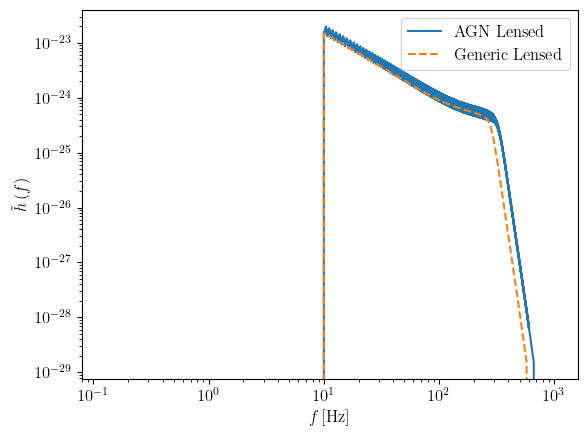

In [9]:
h_idx = 10
v_idx = 10
plt.loglog(freq_grid[:, h_idx, v_idx], np.abs(FD_strain_lensed_2[:, h_idx, v_idx]), label='AGN Lensed')
plt.loglog(freq_grid[:, h_idx, v_idx], np.abs(FD_strain_normal_lensed_2[:, h_idx, v_idx]), linestyle='--', label='Generic Lensed')
plt.xlabel(r'$f\,[\mathrm{Hz}]$')
plt.ylabel(r'$\tilde h\,(f)$')
plt.legend()

# Compute mismatch

In [12]:
mismatch_1_array = np.zeros((n, n))
mismatch_2_array = np.zeros((n, n))
mismatch_3_array = np.zeros((n, n))

for i in tqdm(range(n)):
    for j in range(n):
        freq_array_temp = freq_grid[:, i, j]
        delta_f = freq_array_temp[1]-freq_array_temp[0]
        AGN_temp_1 = FD_strain_lensed_1[:, i, j]
        AGN_temp_2 = FD_strain_lensed_2[:, i, j]
        AGN_temp_3 = FD_strain_lensed_3[:, i, j]

        normal_temp_1 = FD_strain_normal_lensed_1[:, i, j]
        normal_temp_2 = FD_strain_normal_lensed_2[:, i, j]
        normal_temp_3 = FD_strain_normal_lensed_3[:, i, j]

        psd_FS = FrequencySeries(np.asarray(psd_interp), delta_f=delta_f, epoch=0)
        normal_lensed_FS_1 = FrequencySeries(np.asarray(normal_temp_1), delta_f=delta_f, epoch=0)
        normal_lensed_FS_2 = FrequencySeries(np.asarray(normal_temp_2), delta_f=delta_f, epoch=0)
        normal_lensed_FS_3 = FrequencySeries(np.asarray(normal_temp_3), delta_f=delta_f, epoch=0)
        AGN_lensed_FS_1 = FrequencySeries(np.asarray(AGN_temp_1), delta_f=delta_f, epoch=0)
        AGN_lensed_FS_2 = FrequencySeries(np.asarray(AGN_temp_2), delta_f=delta_f, epoch=0)
        AGN_lensed_FS_3 = FrequencySeries(np.asarray(AGN_temp_3), delta_f=delta_f, epoch=0)

        # Compute match
        match_1, _ = match(normal_lensed_FS_1, 
                        AGN_lensed_FS_1, 
                        psd=psd_FS, 
                        low_frequency_cutoff=f_min)
        match_2, _ = match(AGN_lensed_FS_2, 
                        normal_lensed_FS_2, 
                        psd=psd_FS, 
                        low_frequency_cutoff=f_min)
        match_3, _ = match(AGN_lensed_FS_3, 
                        normal_lensed_FS_3, 
                        psd=psd_FS, 
                        low_frequency_cutoff=f_min)

        mismatch_1_array = mismatch_1_array.at[i, j].set(np.full_like(match_1, 1) - match_1)
        mismatch_2_array = mismatch_2_array.at[i, j].set(np.full_like(match_2, 1) - match_2)
        mismatch_3_array = mismatch_3_array.at[i, j].set(np.full_like(match_3, 1) - match_3)

100%|██████████| 100/100 [27:00<00:00, 16.20s/it]  


In [13]:
mismatch_mod_1 = mismatch(freq_grid, FD_strain_lensed_1, FD_strain_normal_lensed_1, psd_interp_grid)
mismatch_mod_2 = mismatch(freq_grid, FD_strain_lensed_2, FD_strain_normal_lensed_2, psd_interp_grid)
mismatch_mod_3 = mismatch(freq_grid, FD_strain_lensed_3, FD_strain_normal_lensed_3, psd_interp_grid)

# Plot mismatch

## Mismatch wrt $R_{\mathrm{orbit}}/R_S$, $\mathcal{M}$, $M_{\mathrm{Lz}}$, $y\equiv \beta/\theta_E$

Text(0, 0.5, '$y\\equiv\\beta/\\theta_E$')

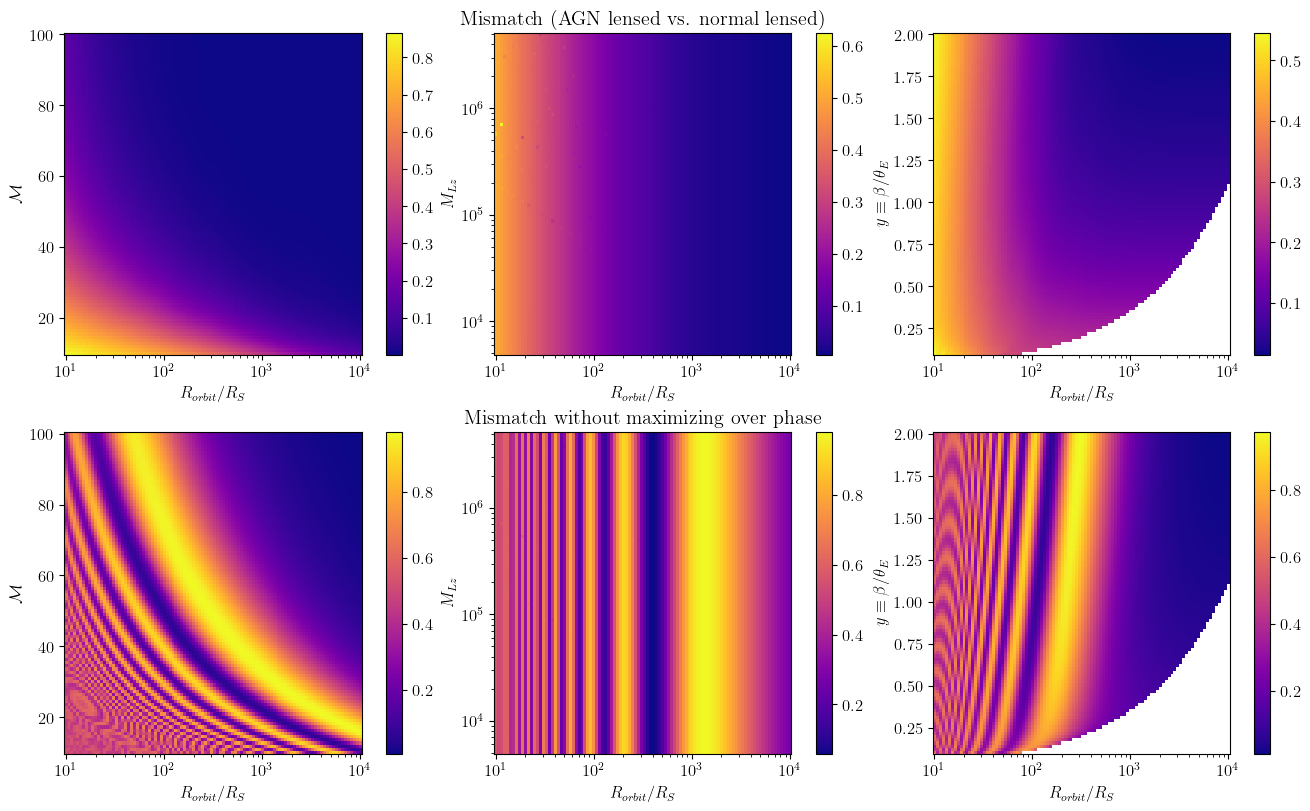

In [14]:
# Plot
fig, axs = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
cmap = plt.cm.plasma

ax = axs[0,0]
im = ax.pcolormesh(R_orbit_array, Mc_array, mismatch_1_array, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}/R_S$')
ax.set_ylabel(r'$\cal M$')

ax = axs[0,1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_2_array, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Mismatch (AGN lensed vs. normal lensed)')
ax.set_xlabel(r'$R_{orbit}/R_S$')
ax.set_ylabel(r'$M_{Lz}$')

ax = axs[0,2]
im = ax.pcolormesh(R_orbit_array, y_array, mismatch_3_array, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}/R_S$')
ax.set_ylabel(r'$y\equiv\beta/\theta_E$')

ax = axs[1, 0]
im = ax.pcolormesh(R_orbit_array, Mc_array, mismatch_mod_1, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}/R_S$')
ax.set_ylabel(r'$\cal M$')

ax = axs[1, 1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_mod_2, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Mismatch without maximizing over phase')
ax.set_xlabel(r'$R_{orbit}/R_S$')
ax.set_ylabel(r'$M_{Lz}$')

ax = axs[1, 2]
im = ax.pcolormesh(R_orbit_array, y_array, mismatch_mod_3, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}/R_S$')
ax.set_ylabel(r'$y\equiv\beta/\theta_E$')

## Compare two mismatch definitions

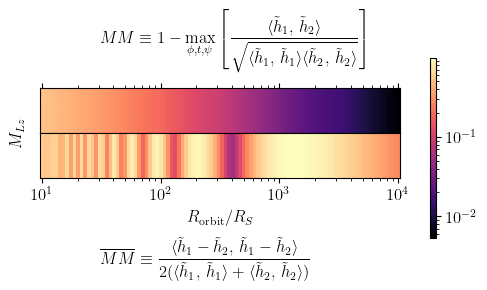

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(6, 3), gridspec_kw={'hspace': 0})
cmap = plt.cm.magma

ax = axs[0]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_2_array, cmap=cmap, norm=LogNorm())
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_title('Mismatch (AGN lensed vs. normal lensed)')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='x', which='both', top=True, bottom=False, labeltop=True, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False)

ax = axs[1]
im2 = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_mod_2, cmap=cmap, norm=LogNorm())
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_yticklabels([])
ax.tick_params(axis='x', which='both', top=False, bottom=True)
ax.tick_params(axis='y', which='both', left=False, right=False)

fig.text(0.2, 0.75, 
         r'$$MM\equiv 1 - \max_{\phi,t,\psi}\left[\frac{\langle \tilde h_1,\,\tilde h_2\rangle}{\sqrt{\langle \tilde h_1,\,\tilde h_1\rangle \langle \tilde h_2,\,\tilde h_2\rangle}}\right]$$'
         )
fig.text(0.2, 0.02, 
         r'$$\overline{MM}\equiv \frac{\langle \tilde h_1-\tilde h_2,\,\tilde h_1-\tilde h_2\rangle}{2(\langle \tilde h_1,\,\tilde h_1\rangle + \langle \tilde h_2,\,\tilde h_2\rangle)}$$'
         )

fig.text(0.05, 0.45, r'$M_{Lz}$', va='center', rotation=90)

vmin = min(np.nanmin(mismatch_2_array), np.nanmin(mismatch_mod_2))
vmax = max(np.nanmax(mismatch_2_array), np.nanmax(mismatch_mod_2))
im.set_clim(vmin, vmax)
im2.set_clim(vmin, vmax)

cax = fig.add_axes([0.75, 0.1, 0.01, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax)

plt.subplots_adjust(left=0.1, right=0.7, top=0.6, bottom=0.3)

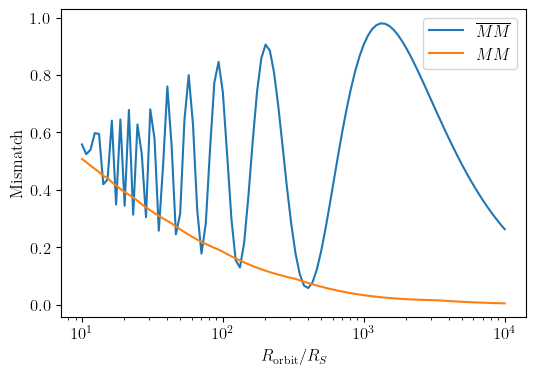

In [17]:
mismatch_slice = mismatch_2_array[0, :]
mismatch_mod_slice = mismatch_mod_2[0, :]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(R_orbit_array, mismatch_mod_slice, label=r'$\overline{MM}$')
ax.plot(R_orbit_array, mismatch_slice, label=r'$MM$')

# peak_locs = [[43, 0.15], [90, 0.065], [550, 0.025]]
# for x_peak, y_peak in peak_locs:
#     ax.annotate('', xy=(x_peak, y_peak), 
#                 xytext=(x_peak, y_peak - 0.02),
#                 arrowprops=dict(arrowstyle='->', color='r', lw=1.5))

ax.set_xscale('log')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel('Mismatch')
ax.legend()